Install Dataset

In [18]:
!wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
!unzip cell_images.zip

--2026-03-08 08:25:08--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.170.73.20, 3.170.73.86, 3.170.73.82, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.170.73.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip.3’

cell_images.zip.3    17%[==>                 ]  59.22M   148MB/s               ^C
Archive:  cell_images.zip
replace cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Import Libraries

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Load Dataset

In [17]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train = datagen.flow_from_directory(
    "cell_images",
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val = datagen.flow_from_directory(
    "cell_images",
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


Build Simple CNN

In [19]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

Compile Model

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model

MobileNetV2 Training Code

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = mobilenet_model.fit(
    train,
    validation_data=val,
    epochs=5
)

/tmp/ipykernel_403/1838689414.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 112s 151ms/step - accuracy: 0.9069 - loss: 0.2388 - val_accuracy: 0.9169 - val_loss: 0.2088
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 99s 144ms/step - accuracy: 0.9419 - loss: 0.1563 - val_accuracy: 0.9270 - val_loss: 0.1924
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 147ms/step - accuracy: 0.9483 - loss: 0.1388 - val_accuracy: 0.9214 - val_loss: 0.2024
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 99s 144ms/step - accuracy: 0.9553 - loss: 0.1279 - val_accuracy: 0.9269 - val_loss: 0.2021
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9573 - loss: 0.1210 - val_accuracy: 0.9269 - val_loss: 0.1981


EfficientNetB0 Training Code

In [22]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(64,64,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

efficient_model = Model(inputs=base_model.input, outputs=predictions)

efficient_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_efficient = efficient_model.fit(
    train,
    validation_data=val,
    epochs=5
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 228ms/step - accuracy: 0.5036 - loss: 0.7030 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 220ms/step - accuracy: 0.4941 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 155s 225ms/step - accuracy: 0.4969 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 163s 237ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 153s 222ms/step - accuracy: 0.5031 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


Plot Accuracy

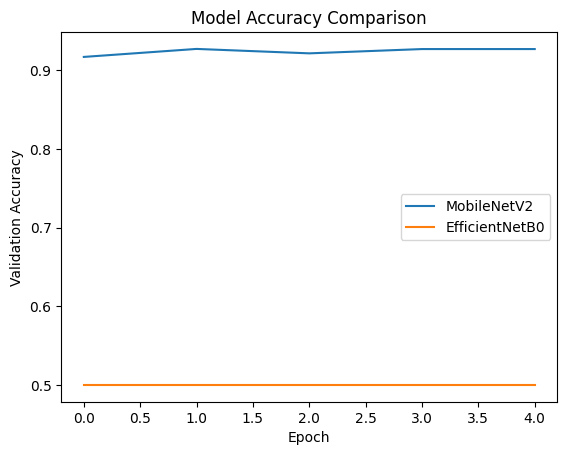

In [23]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2')
plt.plot(history_efficient.history['val_accuracy'], label='EfficientNetB0')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

Save model

In [24]:
model.save("malaria_model.h5")

Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


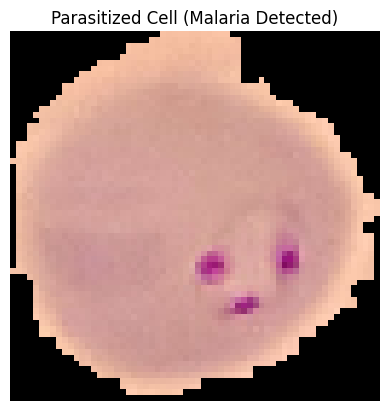

Prediction: Parasitized Cell (Malaria Detected)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Path of test image
img_path = "cell_images/Parasitized/C33P1thinF_IMG_20150619_114756a_cell_179.png"

# Load and preprocess image
img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

# Determine result
if prediction[0][0] > 0.5:
    result = "Uninfected Cell (No Malaria)"
else:
    result = "Parasitized Cell (Malaria Detected)"

# Display image with result
plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()

print("Prediction:", result)